#   Exploratory Data Analysis (EDA)

The objective of this notebook is to explore the dataset, identify
patterns and relationships between features, understand the target
variable, and detect potential data quality issues before data cleaning
and model development.

**1. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**2. Load Dataset**

In [ ]:
df = pd.read_csv("Loan_Default.csv")
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


**3. Target Variable Analysis**

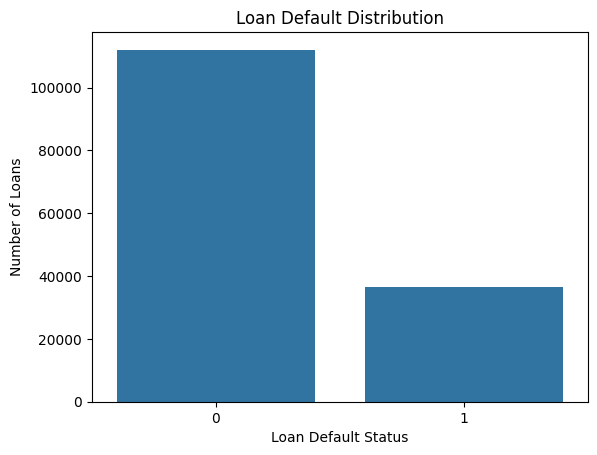

In [3]:
sns.countplot(data=df, x="Status")
plt.title("Loan Default Distribution")
plt.xlabel("Loan Default Status")
plt.ylabel("Number of Loans")

plt.show()

### Observation

The target variable is imbalanced, with approximately 75.36% of
observations belonging to class 0 and 24.64% belonging to class 1.

This indicates a moderate class imbalance that should be considered
during model training and evaluation.

**4. Numerical Features**

In [4]:
numerical_features = df.select_dtypes(include=np.number).columns.tolist()
numerical_features.remove("Status")
numerical_features

['ID',
 'year',
 'loan_amount',
 'rate_of_interest',
 'Interest_rate_spread',
 'Upfront_charges',
 'term',
 'property_value',
 'income',
 'Credit_Score',
 'LTV',
 'dtir1']

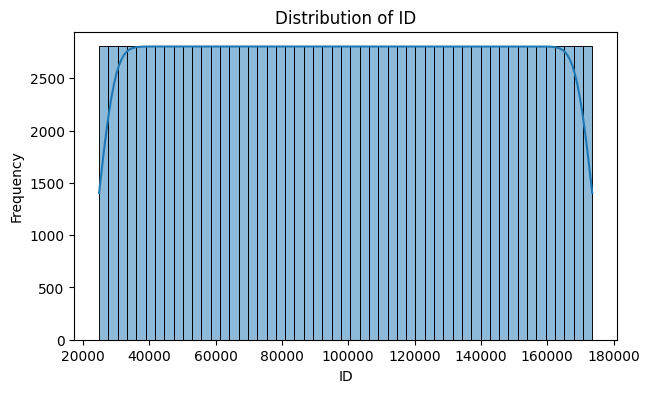

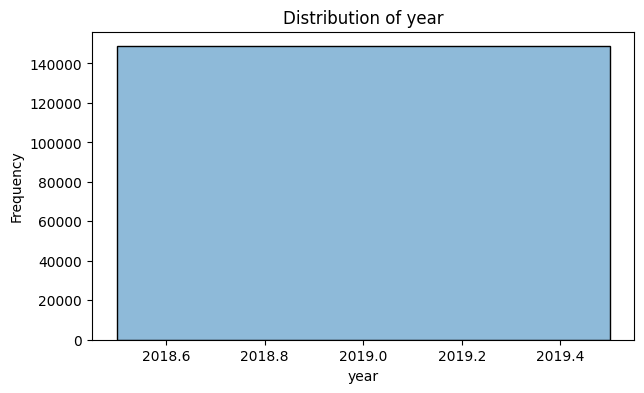

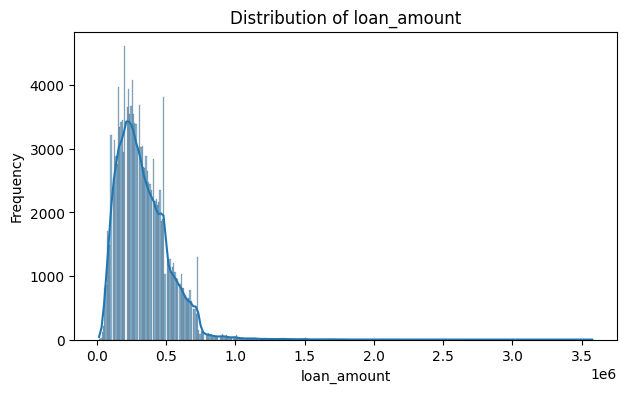

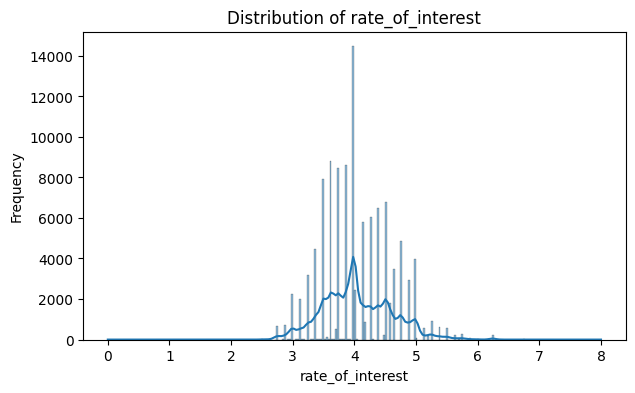

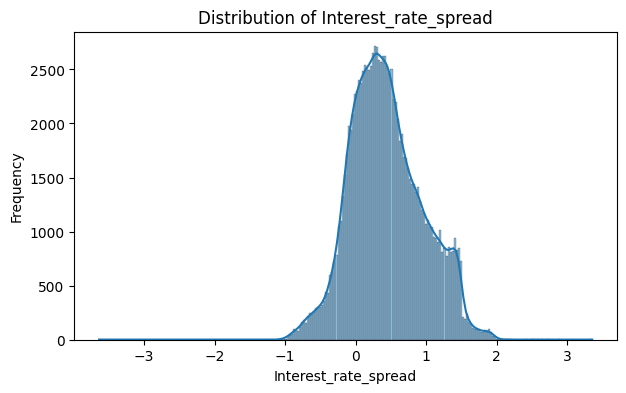

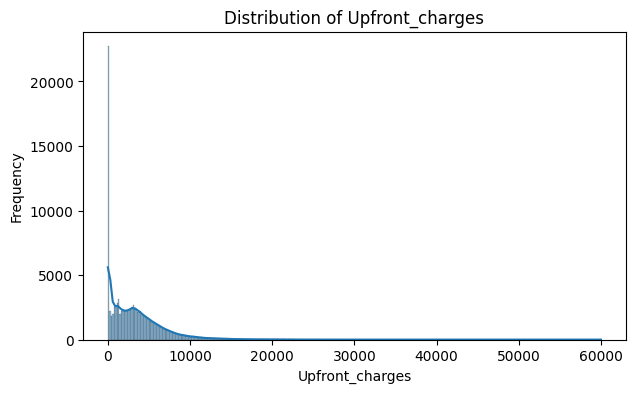

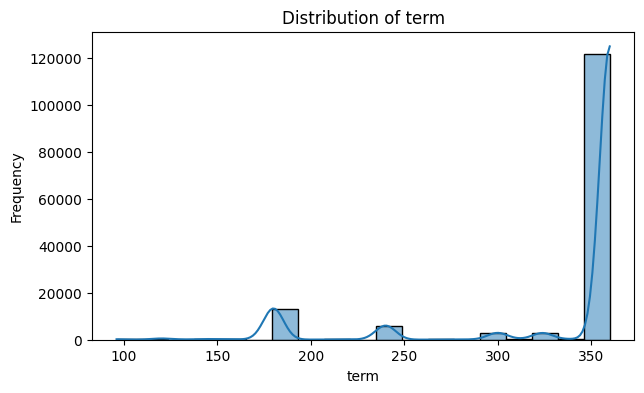

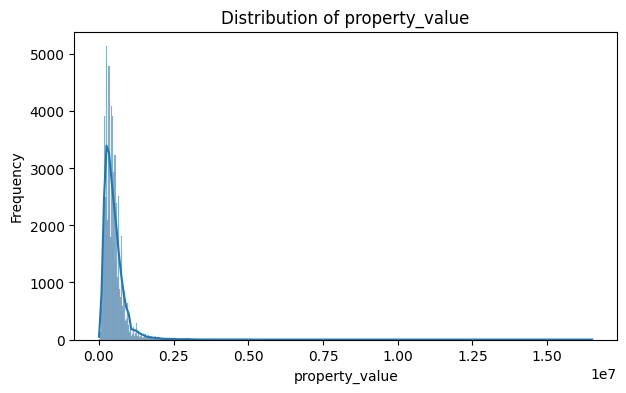

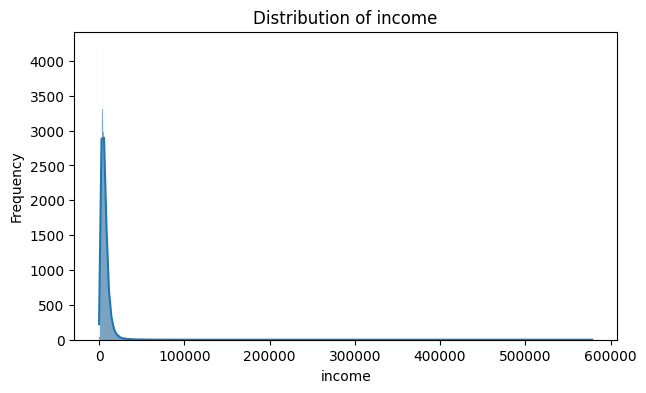

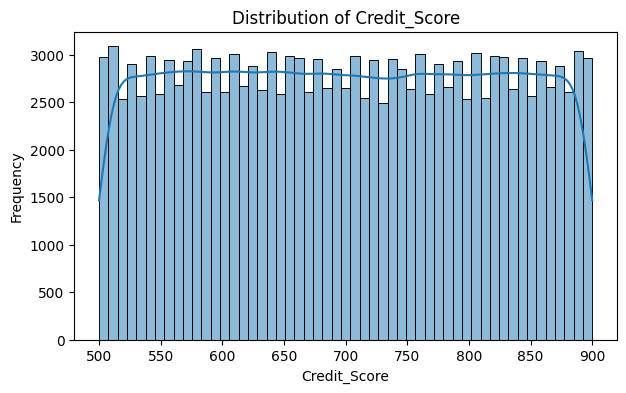

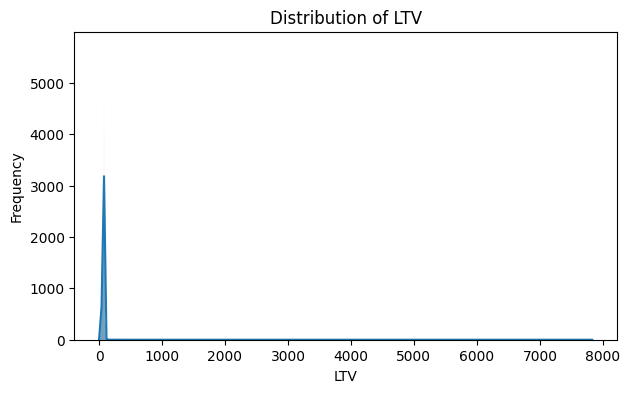

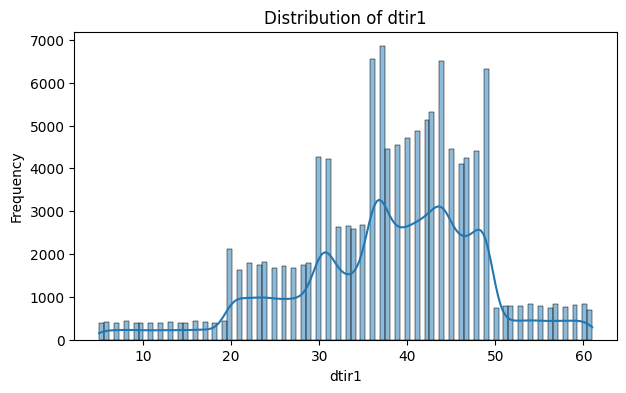

In [5]:
for feature in numerical_features:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df,x=feature,kde=True)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.show()

**5. Outlier Investigation**

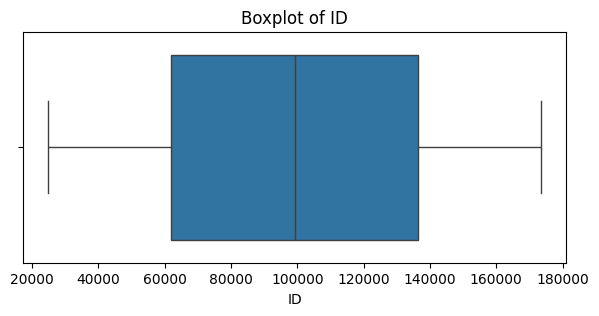

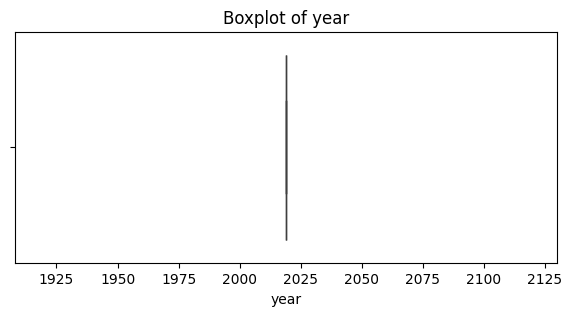

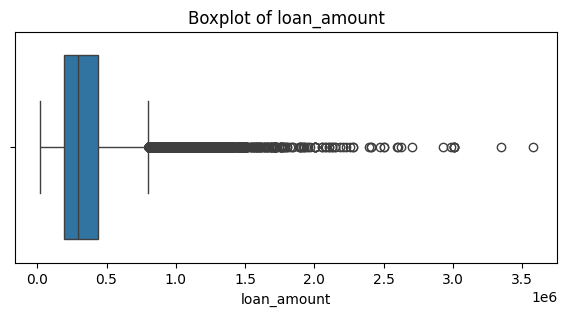

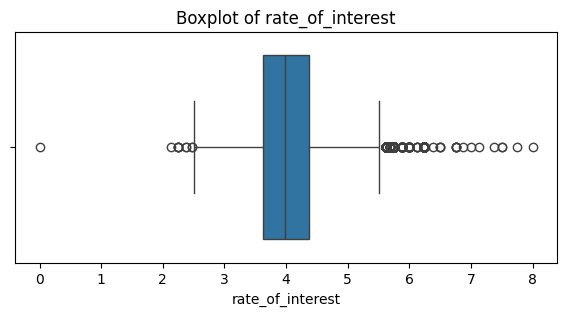

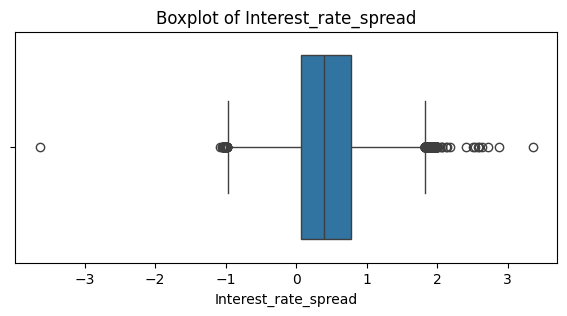

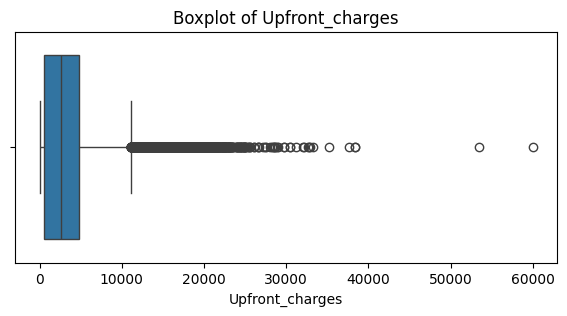

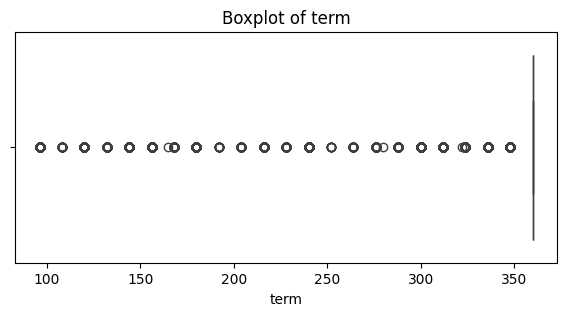

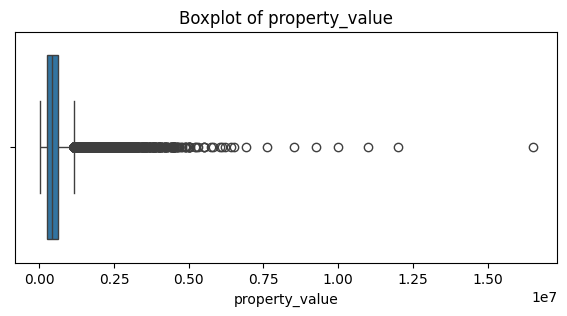

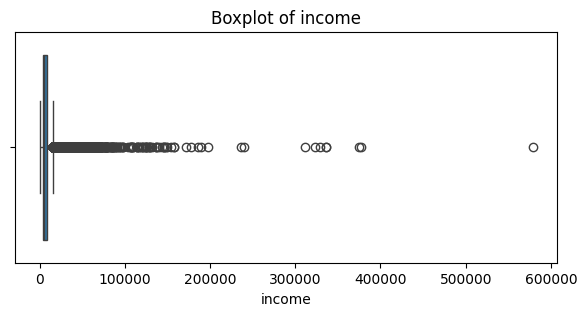

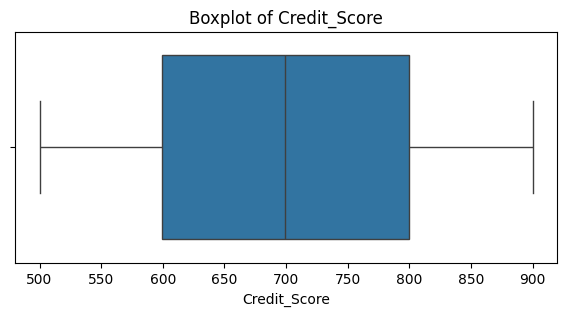

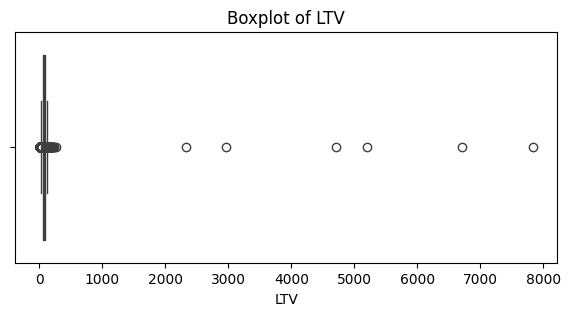

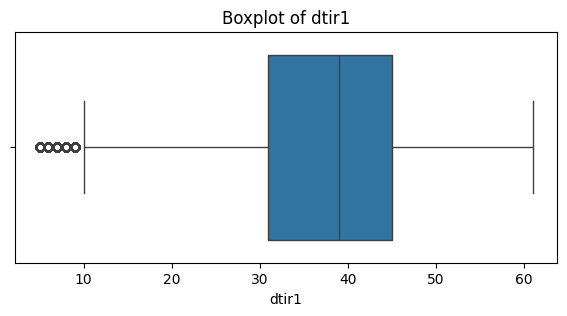

In [6]:
for feature in numerical_features:
    plt.figure(figsize=(7, 3))
    sns.boxplot(data=df,x=feature)
    plt.title(f"Boxplot of {feature}")
    plt.xlabel(feature)

    plt.show()

**6. Categorical Features**

In [7]:
categorical_features = df.select_dtypes(include="object").columns.tolist()
categorical_features

['loan_limit',
 'Gender',
 'approv_in_adv',
 'loan_type',
 'loan_purpose',
 'Credit_Worthiness',
 'open_credit',
 'business_or_commercial',
 'Neg_ammortization',
 'interest_only',
 'lump_sum_payment',
 'construction_type',
 'occupancy_type',
 'Secured_by',
 'total_units',
 'credit_type',
 'co-applicant_credit_type',
 'age',
 'submission_of_application',
 'Region',
 'Security_Type']

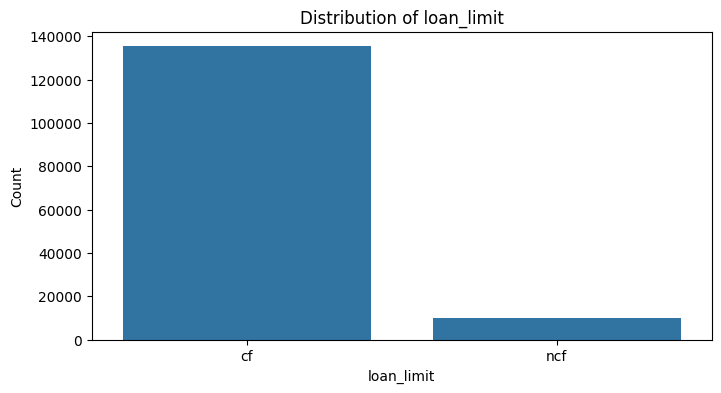

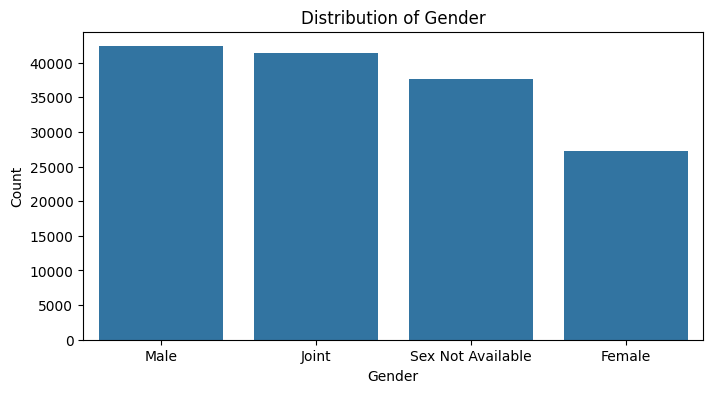

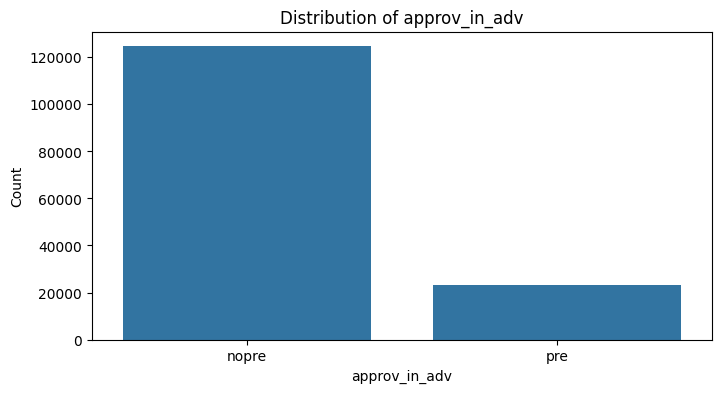

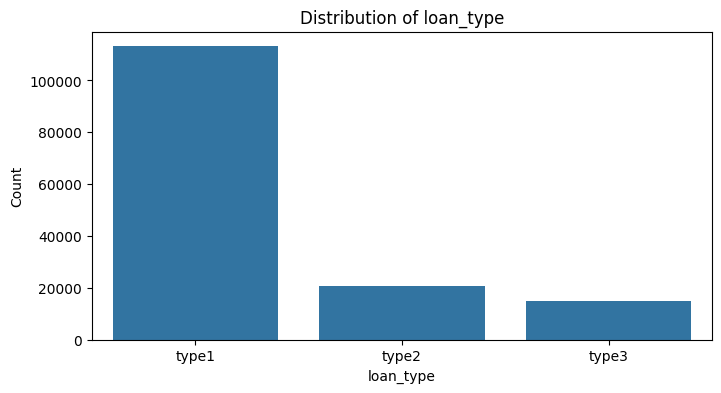

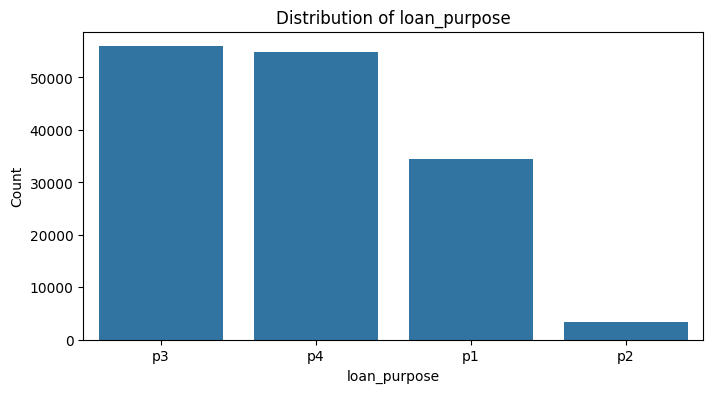

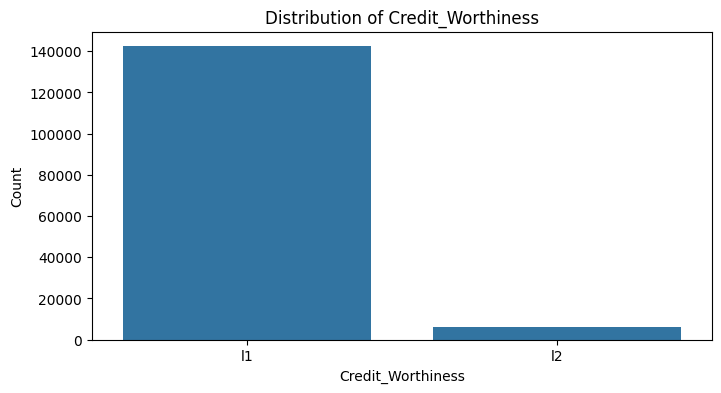

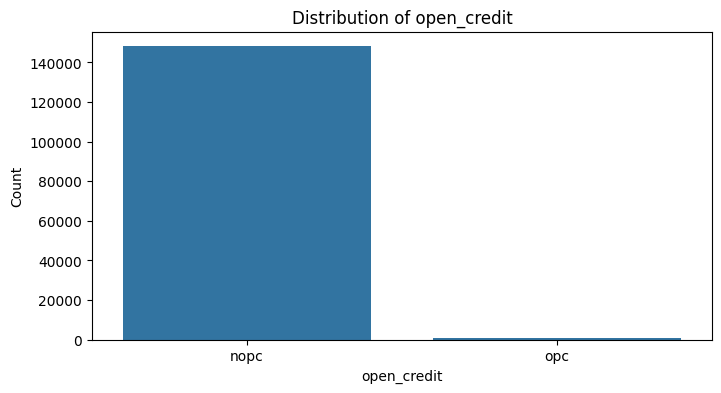

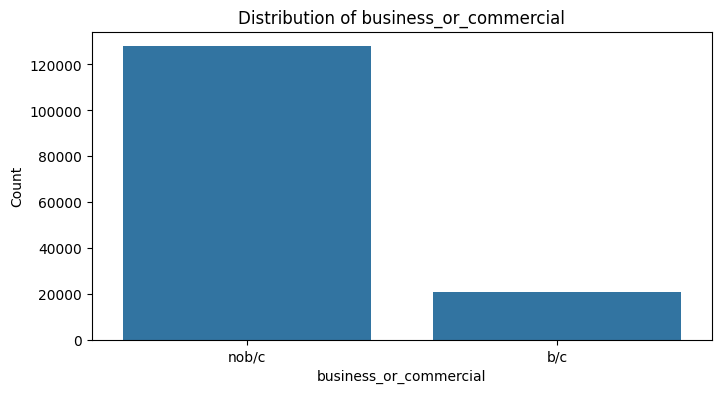

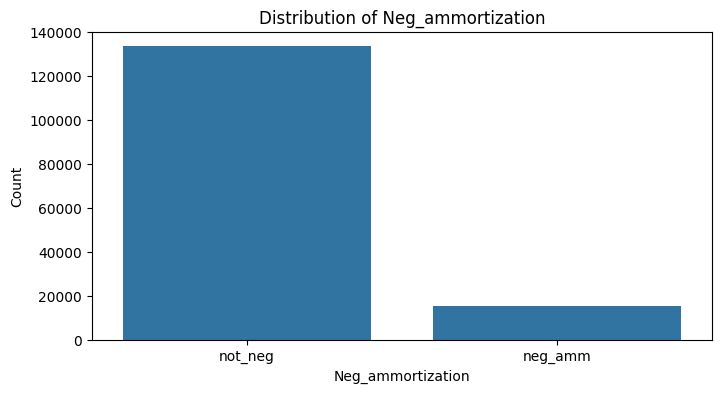

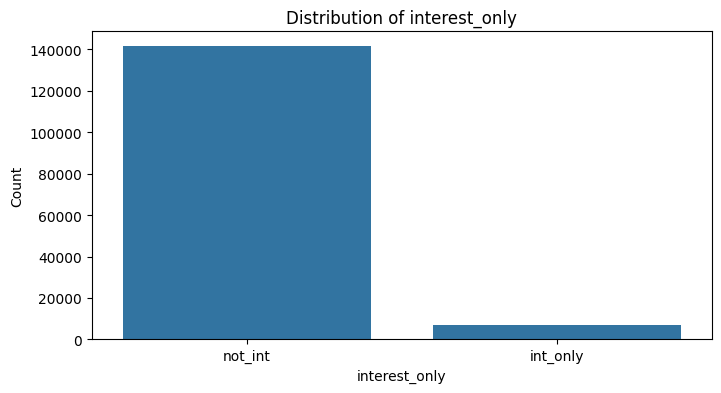

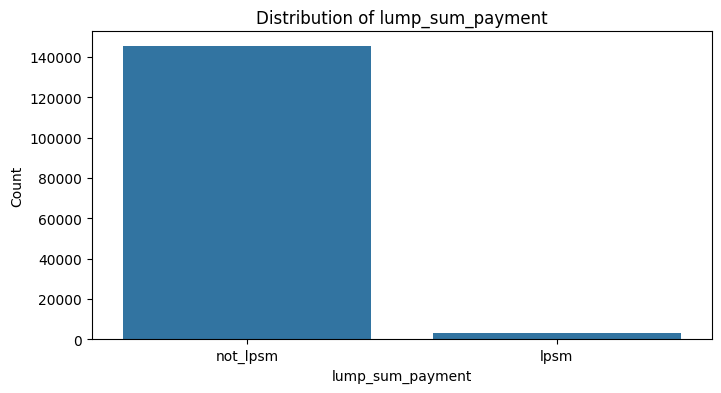

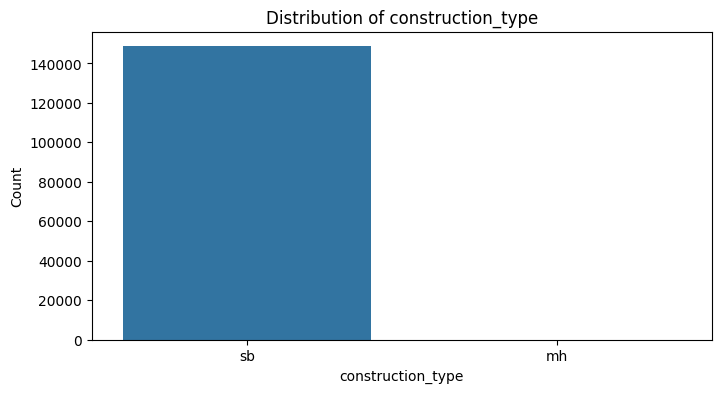

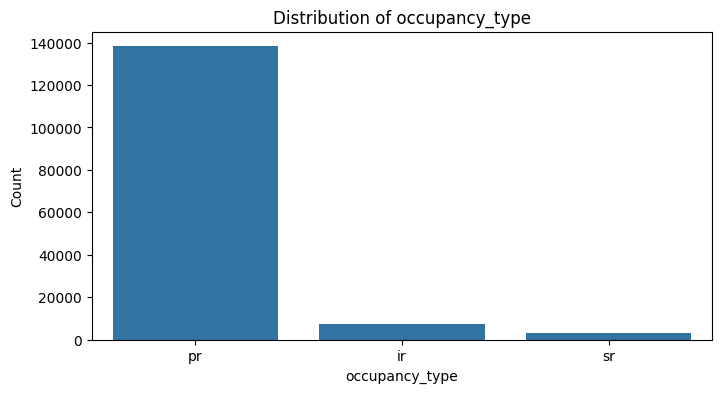

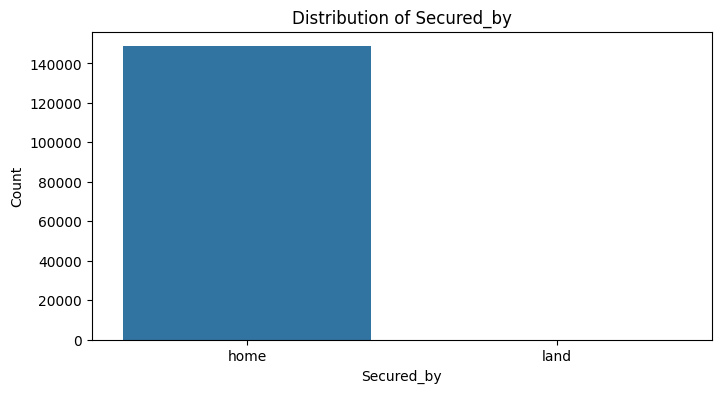

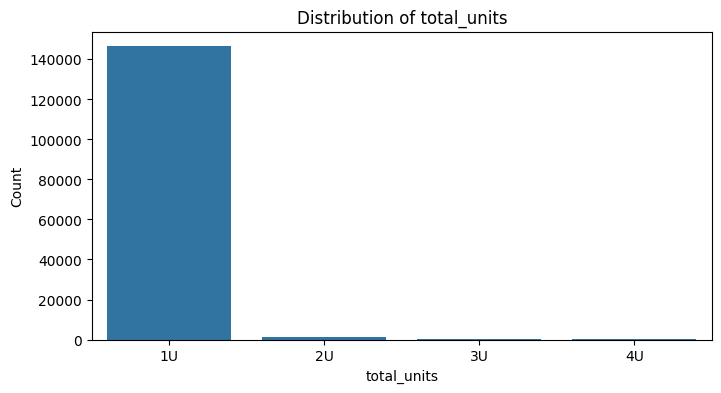

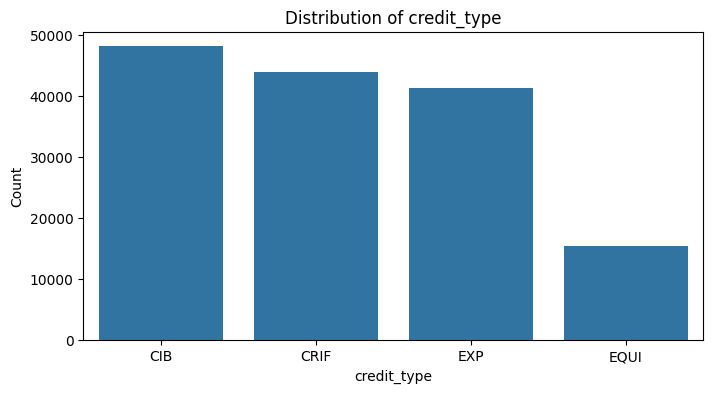

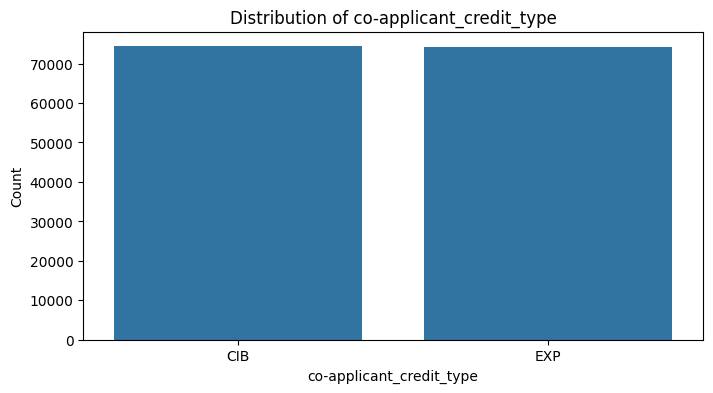

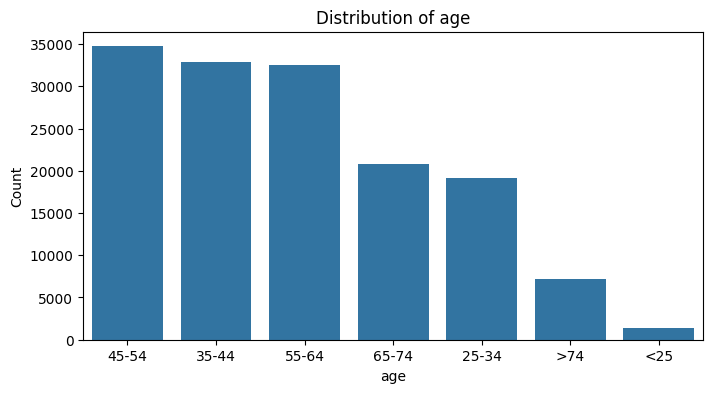

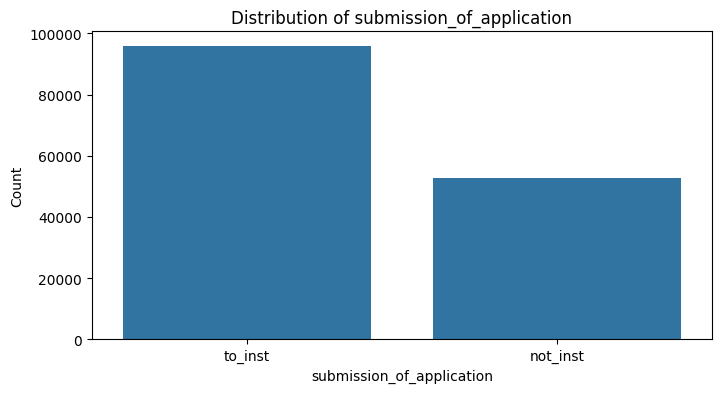

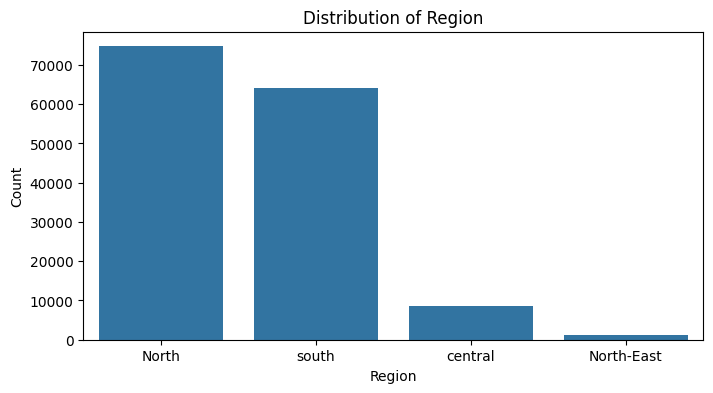

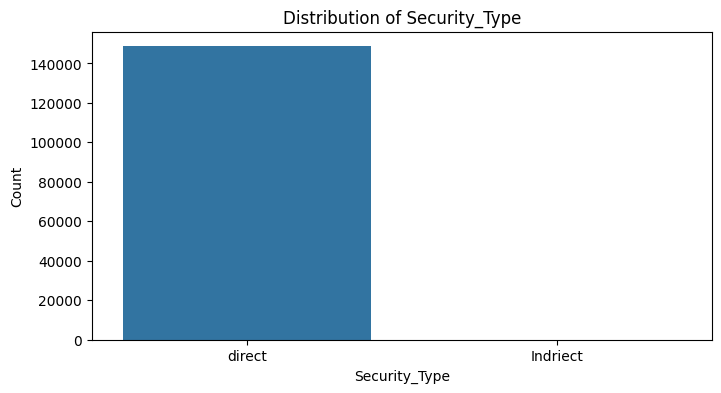

In [10]:
for feature in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df,x=feature,order=df[feature].value_counts().index)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")

    plt.show()

**7. Categorical Features vs Target**

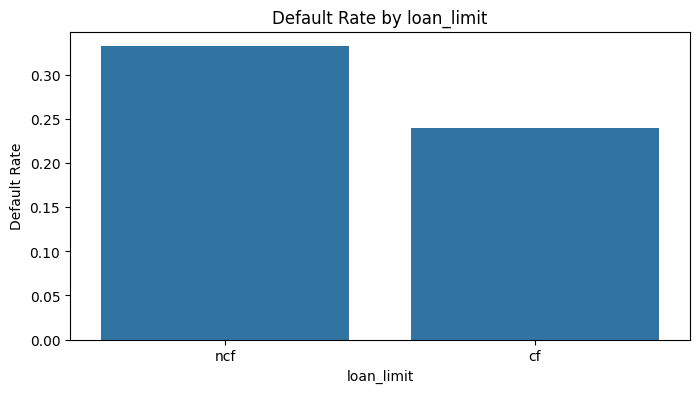

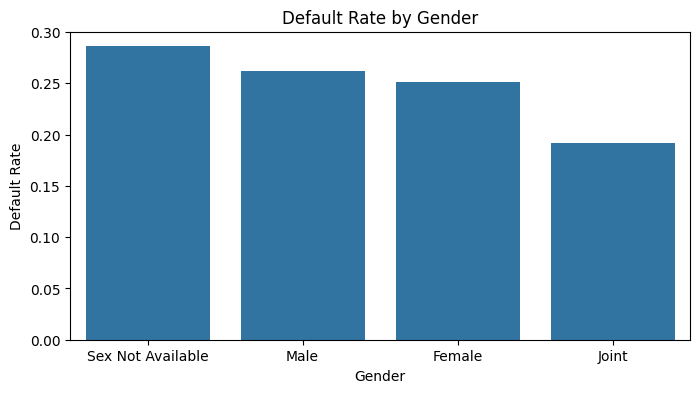

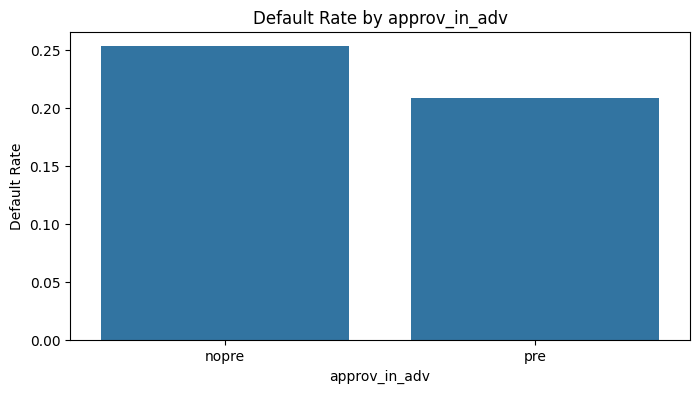

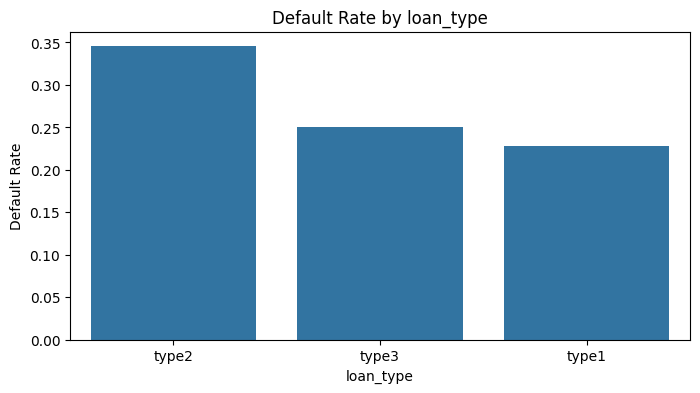

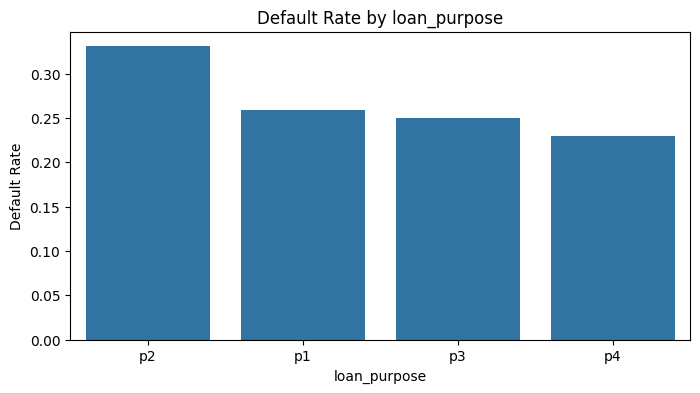

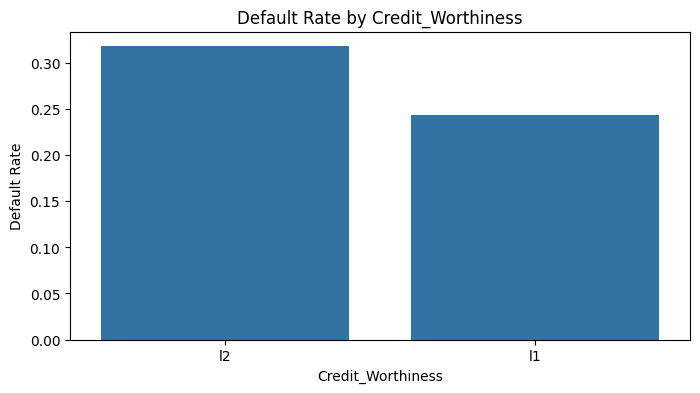

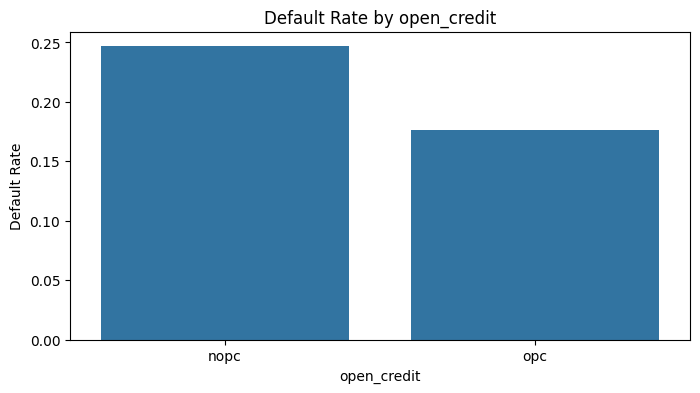

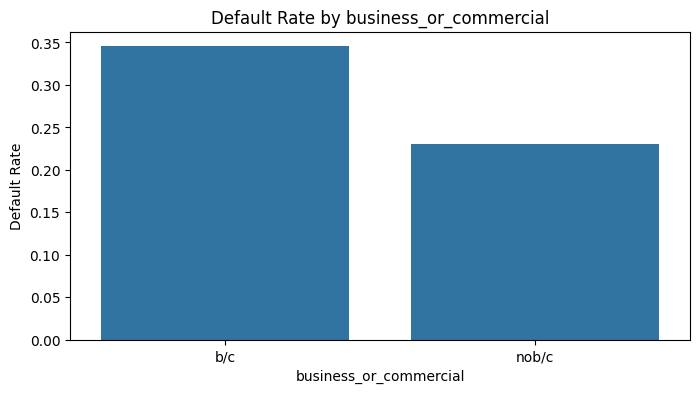

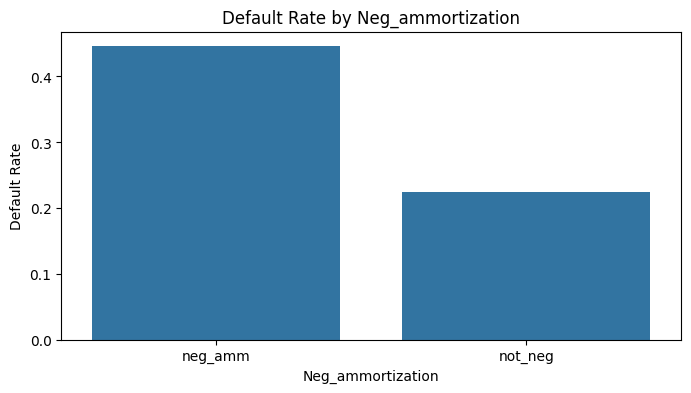

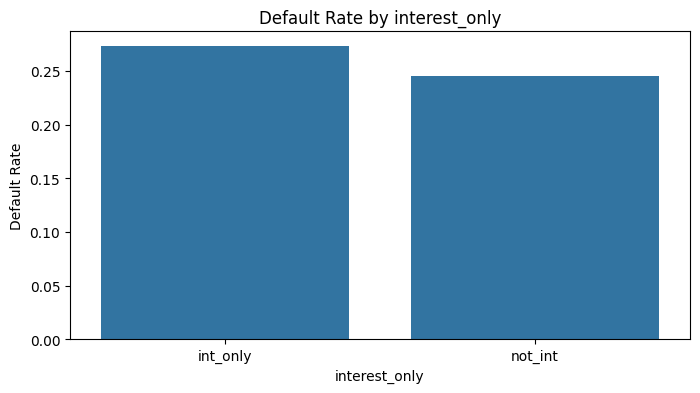

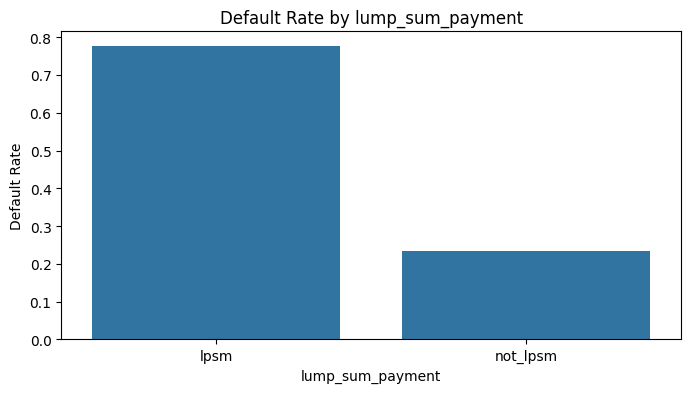

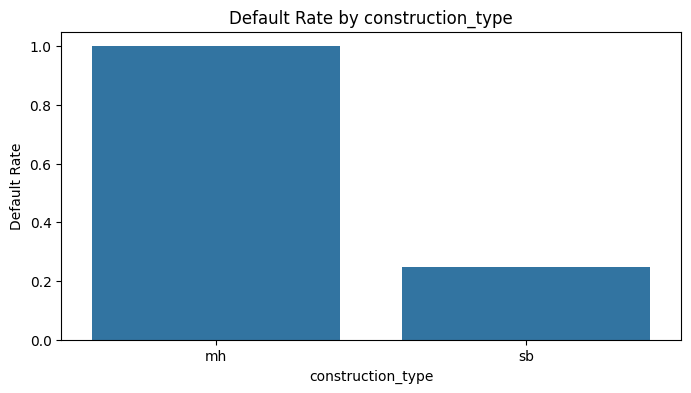

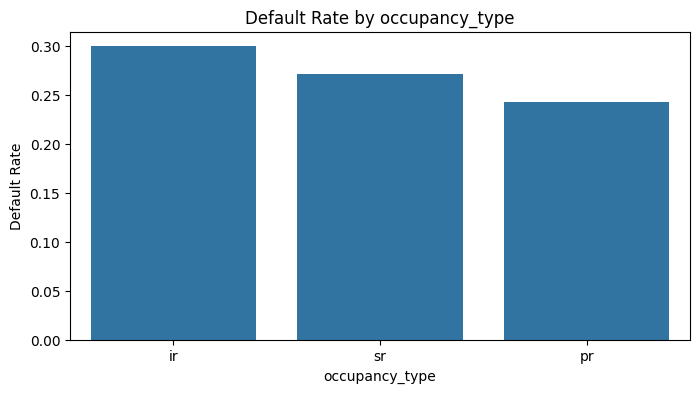

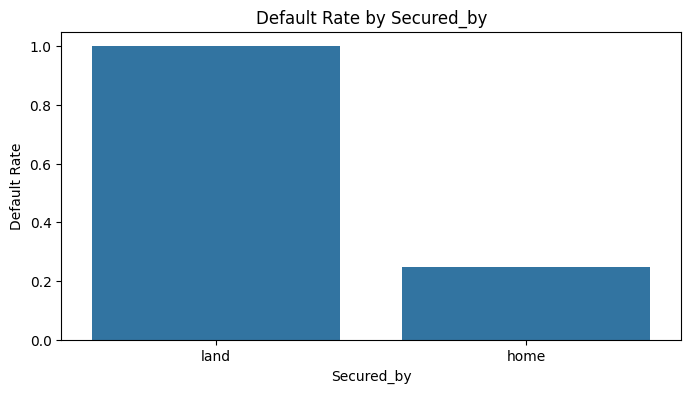

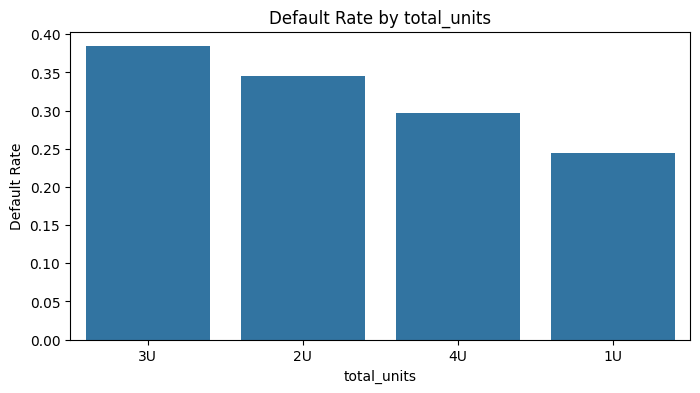

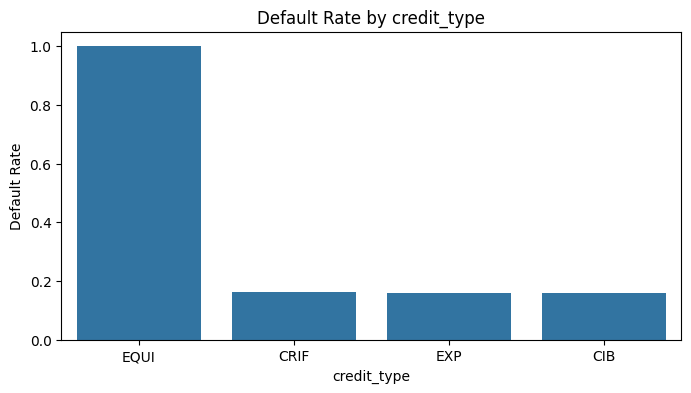

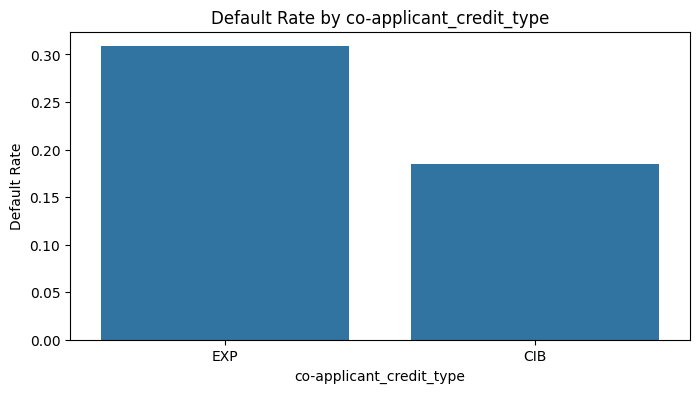

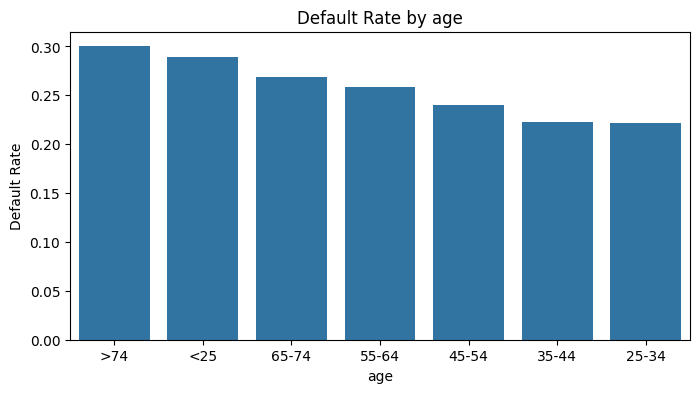

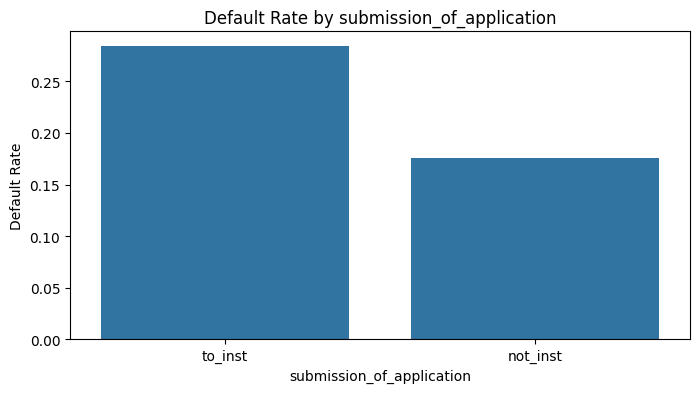

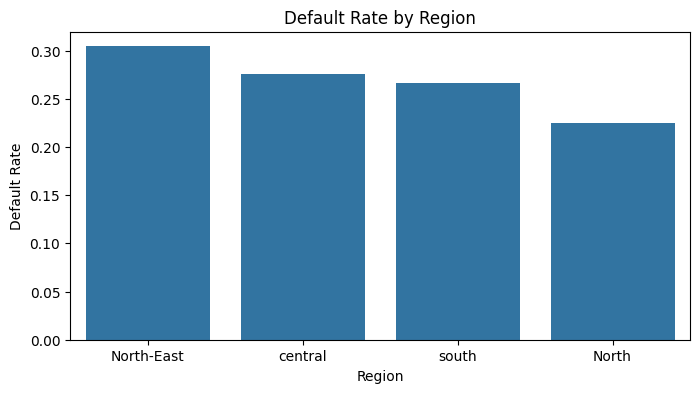

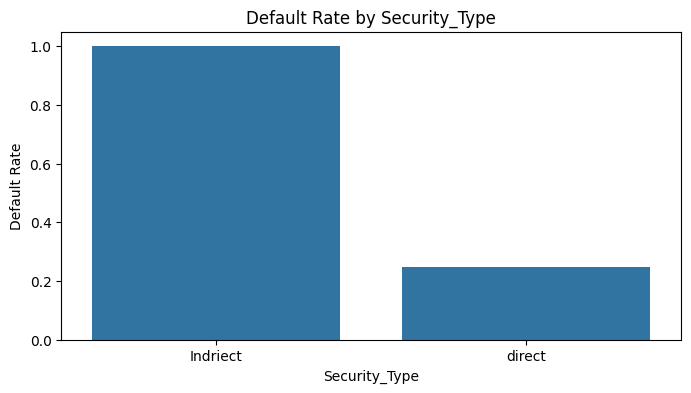

In [14]:
def plot_default_rate(feature):
    default_rate = (df.groupby(feature)["Status"].mean().sort_values(ascending=False))
    plt.figure(figsize=(8, 4))
    sns.barplot(x=default_rate.index,y=default_rate.values)
    plt.title(f"Default Rate by {feature}")
    plt.xlabel(feature)
    plt.ylabel("Default Rate")

    plt.show()
for feature in categorical_features:
    plot_default_rate(feature)

**8. Correlation Matrix**

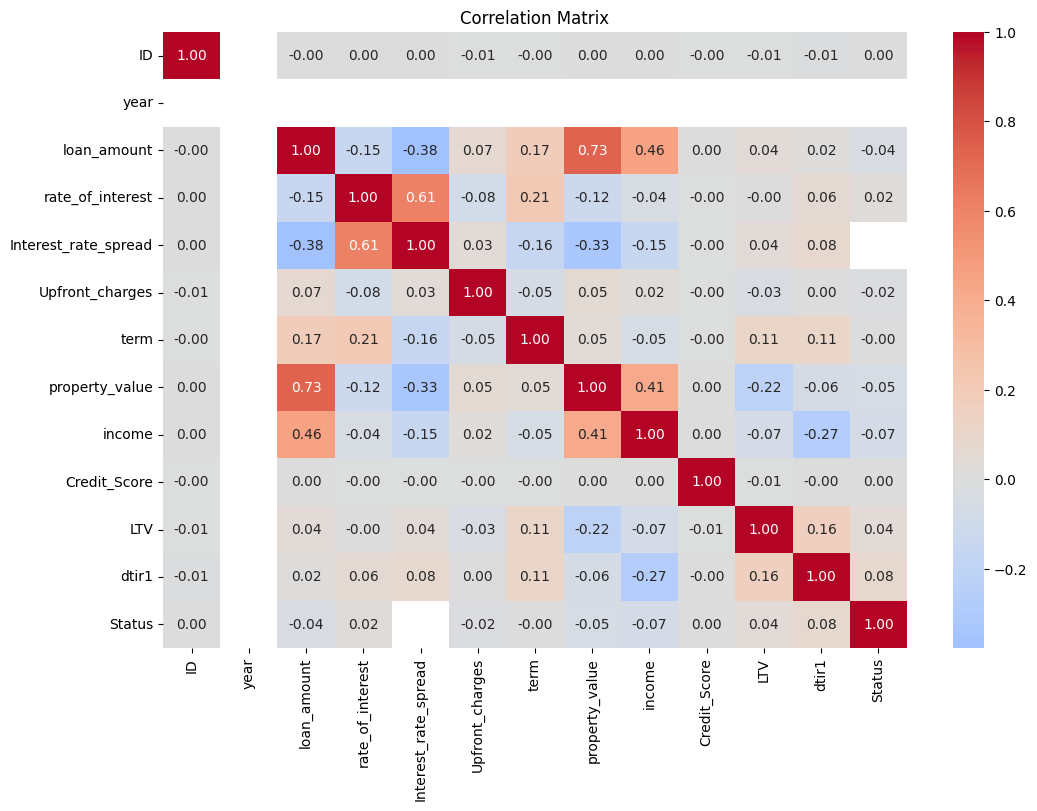

In [23]:
correlation_matrix = df[numerical_features + ["Status"]].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("Correlation Matrix")

plt.show()

9. Missing Values Pattern

In [21]:
missing_features = [
    "rate_of_interest",
    "Interest_rate_spread",
    "Upfront_charges",
    "property_value",
    "income",
    "LTV",
    "dtir1"
]

for feature in missing_features:
    missing_flag = df[feature].isnull().astype(int)
    default_rate = df.groupby(missing_flag)["Status"].mean()

    print(f"\n{feature}")
    print(default_rate)


rate_of_interest
rate_of_interest
0    0.001782
1    1.000000
Name: Status, dtype: float64

Interest_rate_spread
Interest_rate_spread
0    0.0
1    1.0
Name: Status, dtype: float64

Upfront_charges
Upfront_charges
0    0.001403
1    0.920387
Name: Status, dtype: float64

property_value
property_value
0    0.161284
1    0.999868
Name: Status, dtype: float64

income
income
0    0.253727
1    0.135410
Name: Status, dtype: float64

LTV
LTV
0    0.161284
1    0.999868
Name: Status, dtype: float64

dtir1
dtir1
0    0.163221
1    0.676174
Name: Status, dtype: float64


## EDA Findings — Numerical Features

### Constant Features
- `year` contains a single unique value (2019) across the entire
  dataset and therefore provides no predictive information.
- `year` can be considered for removal during feature preprocessing.

### Identifier Features
- `ID` is an identifier rather than a meaningful predictive feature.
- It does not provide useful information for predicting loan default and
  should be excluded from model training.

### Distribution and Outliers
- `loan_amount` shows a right-skewed distribution with several extreme
  observations.
- `LTV` contains extreme values that require further investigation.
- Other numerical variables should also be examined for skewness and
  potential outliers before deciding on a cleaning strategy.

### Correlation Analysis
- `loan_amount` and `property_value` show a relatively strong positive
  correlation (~0.73).
- `rate_of_interest` and `Interest_rate_spread` show a moderate positive
  correlation (~0.61).
- `loan_amount` and `income` show a moderate positive correlation (~0.46).
- `loan_amount` and `property_value` may require further investigation
  for potential multicollinearity, particularly for linear models.

### Relationship with Target
- The numerical features show relatively weak linear correlations with
  `Status`.
- Weak Pearson correlation does not necessarily indicate that a feature
  is unimportant for classification, as nonlinear relationships and
  interactions may exist.
- Therefore, numerical features will not be removed solely based on
  their correlation with the target.